1. Do a scatterplot of each subject's left telencephalon **(type 1 level 1) volume** by their right (left on the vertical axis and right on the horizontal). The kirby 21 dataset can be found [here](https://raw.githubusercontent.com/bcaffo/ds4bme_intro/master/data/kirby21.csv)
2. Create a vector of the left telencelphalon **(type 1 level 1) volume** values and the right. Demean each. Fit a regression through the origin model with the left telecephalon as the outcome and the right as the predictor. Also do the same with the left as the predictor and the right as the outcome. Plot the fitted lines on your scatterplot.
3. Consider a regression through the origin model $Y=BX$. What would be the impact on the estimate of $B$ if we replaced $X$ by $cX$ where $c$ is a positive constant?
4. Let $X_i$ be a group indicator so that
$$
X_i = I(i \in G_1)
$$
I.e. takes the value $1$ when $i$ is in group 1 and 0 if $i$ is in group 0. Consider optimizing
$$
\sum_{i=1}^n (Y_i - \beta_0 - \beta_1 X_i)^2.
$$
If $\hat Y = \hat \beta_0 + \hat \beta_1 X$ argue that $\hat Y$ is the group mean for group 1 if $X=1$ and the group mean for group 0 if $X=0$.
5. Write a python function that takes an X and Y vector and returns an estimated $\beta_0$ and $\beta_1$ from linear regression using only basic functions such as mean, sd and correlation.
6. Argue that if you take the vectors $Y$ and $X$ and divide them by their standard deviations (respectively), the slope for either regressing $Y$ on $X$ or $X$ on $Y$ is simply the correlation. Note formal proof is not required, just the argument.

## Question 1

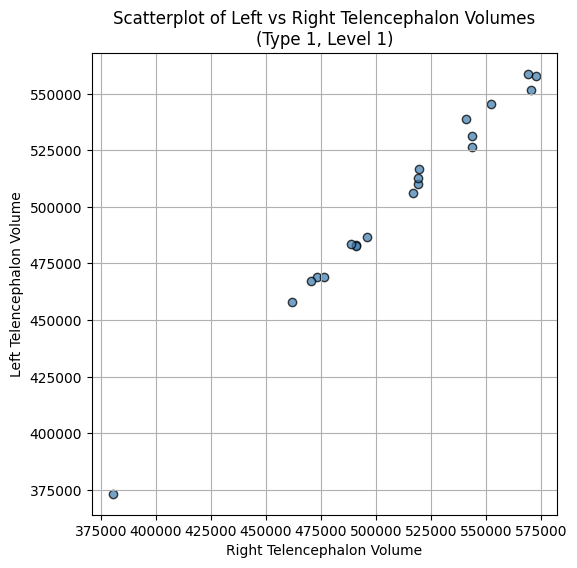

In [1]:
# Q1: Scatterplot of Left vs Right Telencephalon Volumes (Type 1, Level 1)

import pandas as pd
import matplotlib.pyplot as plt

# Load the Kirby21 dataset
data_url = "https://raw.githubusercontent.com/bcaffo/ds4bme_intro/master/data/kirby21.csv"
kirby = pd.read_csv(data_url)

# Select only type 1, level 1 measurements for the telencephalon a stated by the assignment
mask = (kirby["type"] == 1) & (kirby["level"] == 1) & (kirby["roi"].isin(["Telencephalon_L", "Telencephalon_R"]))
subset = kirby.loc[mask, ["id", "roi", "volume"]]

# Separate into left and right tables for later use
left_tbl = subset[subset["roi"] == "Telencephalon_L"].set_index("id")
right_tbl = subset[subset["roi"] == "Telencephalon_R"].set_index("id")

# Align on subject id and extract vectors
merged = left_tbl.join(right_tbl, lsuffix="_L", rsuffix="_R")
left_vals = merged["volume_L"].to_numpy()
right_vals = merged["volume_R"].to_numpy()

# Scatterplot
plt.figure(figsize=(6,6))
plt.scatter(right_vals, left_vals, color="steelblue", alpha=0.75, edgecolor="k")
plt.xlabel("Right Telencephalon Volume")
plt.ylabel("Left Telencephalon Volume")
plt.title("Scatterplot of Left vs Right Telencephalon Volumes\n(Type 1, Level 1)")
plt.grid(True)
plt.show()



## Question 2

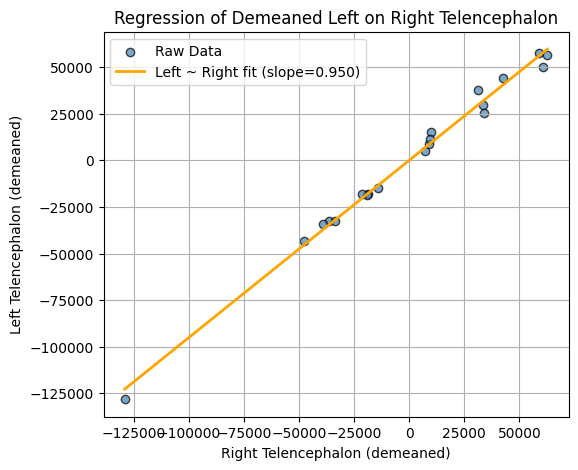

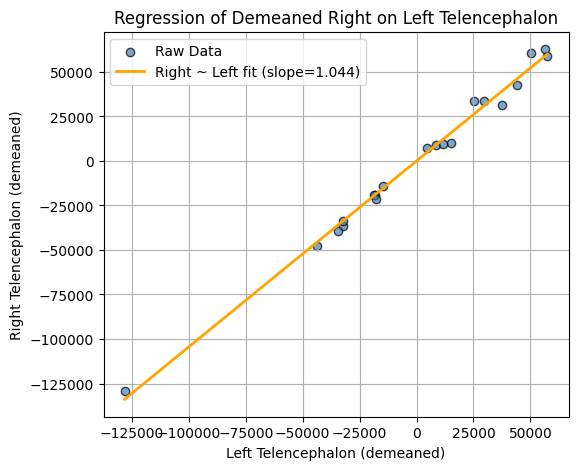

Left on Right Regression Slope: 0.9500552111008128
Right on Left Regression Slope: 1.044241539832241


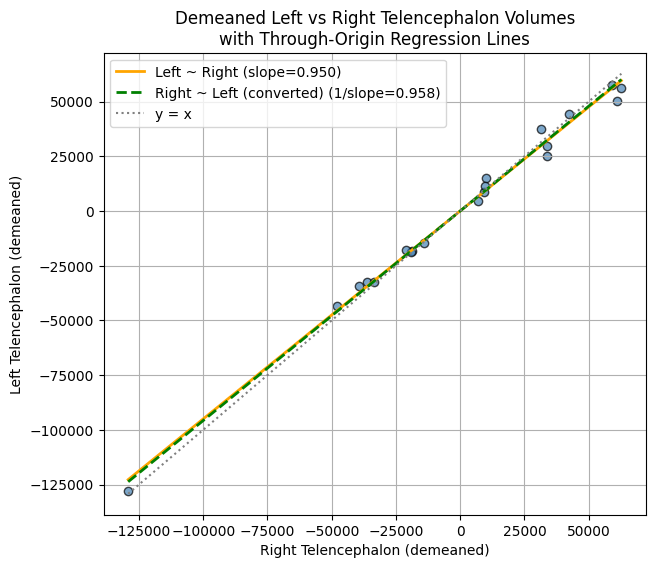

In [13]:
## Question 2: Regressions & Combined Plot
import numpy as np
import matplotlib.pyplot as plt

# Demean left and right telencephalon vectors
left_dm = left_vals - np.mean(left_vals)
right_dm = right_vals - np.mean(right_vals)

# ---------------------------
# Separate regression plots
# ---------------------------

# Left ~ Right (through origin)
slope_lr = np.sum(left_dm * right_dm) / np.sum(right_dm**2)
x_lr = np.linspace(min(right_dm), max(right_dm), 100)

plt.figure(figsize=(6,5))
plt.scatter(right_dm, left_dm, label='Raw Data', color='steelblue', edgecolor='k', alpha=0.7)
plt.plot(x_lr, slope_lr * x_lr, color='orange', linewidth=2,
         label=f'Left ~ Right fit (slope={slope_lr:.3f})')
plt.xlabel('Right Telencephalon (demeaned)')
plt.ylabel('Left Telencephalon (demeaned)')
plt.title('Regression of Demeaned Left on Right Telencephalon')
plt.legend()
plt.grid(True)
plt.show()

# Right ~ Left (through origin)
slope_rl = np.sum(right_dm * left_dm) / np.sum(left_dm**2)
x_rl = np.linspace(min(left_dm), max(left_dm), 100)

plt.figure(figsize=(6,5))
plt.scatter(left_dm, right_dm, label='Raw Data', color='steelblue', edgecolor='k', alpha=0.7)
plt.plot(x_rl, slope_rl * x_rl, color='orange', linewidth=2,
         label=f'Right ~ Left fit (slope={slope_rl:.3f})')
plt.xlabel('Left Telencephalon (demeaned)')
plt.ylabel('Right Telencephalon (demeaned)')
plt.title('Regression of Demeaned Right on Left Telencephalon')
plt.legend()
plt.grid(True)
plt.show()

print("Left on Right Regression Slope:", slope_lr)
print("Right on Left Regression Slope:", slope_rl)

# ---------------------------
# Combined plot
# ---------------------------
plt.figure(figsize=(7,6))
plt.scatter(right_dm, left_dm, color='steelblue', edgecolor='k', alpha=0.7)

# X-axis range
t = np.linspace(right_dm.min(), right_dm.max(), 100)

# Left ~ Right line
plt.plot(t, slope_lr * t, color='orange', linewidth=2, label=f'Left ~ Right (slope={slope_lr:.3f})')

# Right ~ Left line converted for same axes
plt.plot(t, (1/slope_rl) * t, color='green', linestyle='--', linewidth=2,
         label=f'Right ~ Left (converted) (1/slope={1/slope_rl:.3f})')

# Identity line for reference
lims = [min(right_dm.min(), left_dm.min()), max(right_dm.max(), left_dm.max())]
plt.plot(lims, lims, color='gray', linestyle=':', label='y = x')

plt.xlabel('Right Telencephalon (demeaned)')
plt.ylabel('Left Telencephalon (demeaned)')
plt.title('Demeaned Left vs Right Telencephalon Volumes\nwith Through-Origin Regression Lines')
plt.legend()
plt.grid(True)
plt.show()


## Question 3

Consider a regression through the origin:

$$
Y = B X
$$

The least-squares estimate of slope is

$$
B = \frac{\sum_{i=1}^{n} Y_i X_i}{\sum_{i=1}^{n} X_i^2}.
$$

Scaling $X$ by a positive constant $c$, replacing $X$ with $cX$,slope becomes

$$
B' = \frac{\sum_{i=1}^{n} Y_i (c X_i)}{\sum_{i=1}^{n} (c X_i)^2} = \frac{1}{c} \frac{\sum_{i=1}^{n} Y_i X_i}{\sum_{i=1}^{n} X_i^2} = \frac{B}{c}.
$$

Basically, in other words, multiplying all values of $X$ by $c$ divides the slope by $c$. For $c > 1$, the line would mathematically be less steep; for $0 < c < 1$, the line would of course be steeper.


## Question 4




Let $X_i$ be a group indicator defined by

$$
X_i =
\begin{cases}
1 & \text{if observation } i \text{ is in group 1},\\
0 & \text{if observation } i \text{ is in group 0}.
\end{cases}
$$

Consider the linear model

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i,
$$

where $\beta_0$ and $\beta_1$ are estimated by minimizing the sum of squared errors

$$
S = \sum_{i=1}^{n} (Y_i - \beta_0 - \beta_1 X_i)^2.
$$



### Estimation of Parameters

The predicted values for each group are

$$
\hat Y_i =
\begin{cases}
\hat \beta_0 & \text{if } X_i = 0,\\
\hat \beta_0 + \hat \beta_1 & \text{if } X_i = 1.
\end{cases}
$$

Let $\bar Y_0$ and $\bar Y_1$ denote the sample means of $Y$ in group 0 and group 1, respectively. Then the least squares estimates satisfy

$$
\hat \beta_0 = \bar Y_0, \quad \hat \beta_1 = \bar Y_1 - \bar Y_0.
$$


### Predicted Values

$$
\hat Y_i =
\begin{cases}
\bar Y_0 & \text{if } X_i = 0,\\
\bar Y_1 & \text{if } X_i = 1.
\end{cases}
$$

Thus, the fitted values for each observation coincide with the **group means**, and the slope $\hat \beta_1$ represents the difference between the group means, while the intercept $\hat \beta_0$ represents the mean of group 0.


## Question 5

In [23]:
import numpy as np

def linear_regression(X, Y):
    """
    Estimates linear regression coefficients B0 and B1 using only mean, std, and correlation.

    Parameters:
    X (array-like): Predictor variable
    Y (array-like): Response variable

    Returns:
    B0 (float): Intercept
    B1 (float): Slope
    """
    X = np.ravel(X)
    Y = np.ravel(Y)

    # Compute correlation
    corr = np.corrcoef(X, Y)[1, 0]

    # Compute standard deviations
    std_X = np.std(X, ddof=0)  # population std
    std_Y = np.std(Y, ddof=0)

    # Compute slope and intercept
    B1 = corr * (std_Y / std_X)
    B0 = np.mean(Y) - B1 * np.mean(X)

    return B0, B1

# Example usage
X = [3, 4, 5, 6, 7]
Y = [6, 7, 8, 9, 10]
B0, B1 = linear_regression(X, Y)
print("Intercept B0:", B0)
print("Slope B1:", B1)


Intercept B0: 3.000000000000001
Slope B1: 0.9999999999999999


## Question 6

***Question 6***

If we standardize the vectors $X$ and $Y$ by dividing each by its standard deviation, we define:

$$
X' = \frac{X}{\text{SD}(X)}, \quad
Y' = \frac{Y}{\text{SD}(Y)}
$$

The slope of a simple linear regression of $Y$ on $X$ is given by:

$$
\beta_1 = \text{Cor}(X,Y) \frac{\text{SD}(Y)}{\text{SD}(X)}
$$

Substituting the standardized variables $X'$ and $Y'$:

$$
\text{SD}(X') = \text{SD}\Big(\frac{X}{\text{SD}(X)}\Big) = \frac{\text{SD}(X)}{\text{SD}(X)} = 1
$$

$$
\text{SD}(Y') = \text{SD}\Big(\frac{Y}{\text{SD}(Y)}\Big) = \frac{\text{SD}(Y)}{\text{SD}(Y)} = 1
$$

Since the slope formula involves the ratio of standard deviations, we now have:

$$
\beta_1' = \text{Cor}(X', Y') \frac{\text{SD}(Y')}{\text{SD}(X')} = \text{Cor}(X', Y') \frac{1}{1} = \text{Cor}(X', Y')
$$

Thus, after standardization, the regression slope is **exactly equal to the correlation**.  

Because correlation is symmetric, this argument works whether we regress $Y'$ on $X'$ or $X'$ on $Y'$.
